# Advanced NumPy for Physics

This notebook follows up on the basics of `numpy`. We will explore powerful techniques for data manipulation and solving systems of equations, which are common tasks in computational physics and data analysis.

<span style="font-size:12px; color:gray;">
Roughly half of this notebook is created by Gemini. To lazy specify.
</span>

## Boolean Indexing and Masking

Boolean indexing, or masking, is a powerful feature that allows you to select elements from an array based on a condition. When you apply a condition to an array (e.g., `data > 5`), NumPy returns a new array of the same shape, filled with `True` or `False` values. This boolean array is called a **mask**.

You can then use this mask to index the original array, which will return only the elements corresponding to a `True` value. This is incredibly efficient for filtering data, removing outliers, or selecting events that meet a certain criterion.

In [1]:
import numpy as np
from scipy import constants as const
import matplotlib.pyplot as plt
import scipy.misc

# Example: Filtering temperature data
temperatures = np.array([18.2, 25.1, 31.5, 19.8, 15.3, 28.9])

# 1. Create a boolean mask
is_hot_mask = temperatures > 25

# 2. Use the mask to select data
hot_temperatures = temperatures[is_hot_mask]

print(f"Original temperatures: {temperatures}")
print(f"The mask (temp > 25): {is_hot_mask}")
print(f"Hot temperatures (> 25°C): {hot_temperatures}")

# You can also use masks to modify data. Let's cap any temperature above 30.
temperatures[temperatures > 30] = 30
print(f"Capped temperatures: {temperatures}")

Original temperatures: [18.2 25.1 31.5 19.8 15.3 28.9]
The mask (temp > 25): [False  True  True False False  True]
Hot temperatures (> 25°C): [25.1 31.5 28.9]
Capped temperatures: [18.2 25.1 30.  19.8 15.3 28.9]


C:\Users\jona\AppData\Local\Temp\ipykernel_58496\4262189198.py:4: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.misc


<span style="background-color: #f8bbd0; color: black; padding: 2px 5px; border-radius: 3px;">**Task B.1**</span> In a particle physics experiment, an array of particle speeds has been recorded. Your task is to clean this data by removing non-physical values.

1. Create a boolean mask that identifies all speeds greater than the speed of light (`const.c`).
2. Use this mask to create a new array called `physical_speeds` that contains only the valid measurements.
3. Find and print the average of the `physical_speeds`.

In [2]:
particle_speeds = np.array([2.5e8, 1.2e8, 3.1e8, 2.9e8, 0.5e8, 4.5e8]) # in m/s

print(f"Original data: {particle_speeds}")
print(f"Speed of light: {const.c:.2e} m/s")

# Your solution here
# 1. Create a mask for speeds less than or equal to c
physical_mask = particle_speeds <= const.c

# 2. Apply the mask to get a clean dataset
physical_speeds = particle_speeds[physical_mask]
print(f"Valid speeds: {physical_speeds}")

# 3. Calculate and print the average of the clean data
average_speed = np.mean(physical_speeds)
print(f"Average valid speed: {average_speed:.2e} m/s")

Original data: [2.5e+08 1.2e+08 3.1e+08 2.9e+08 5.0e+07 4.5e+08]
Speed of light: 3.00e+08 m/s
Valid speeds: [2.5e+08 1.2e+08 2.9e+08 5.0e+07]
Average valid speed: 1.78e+08 m/s


### Masking on 2D Data (Images)

The same masking principle works wonderfully for 2D arrays, like images. An image is just a 2D array of pixel values. We can create a mask to select pixels based on their brightness and modify them. This is a fundamental technique in image processing.

Let's use a public domain test image from the `scipy` library to demonstrate.

**NOTE:** For this part to work, you have to install `pooch`: `conda install pooch`

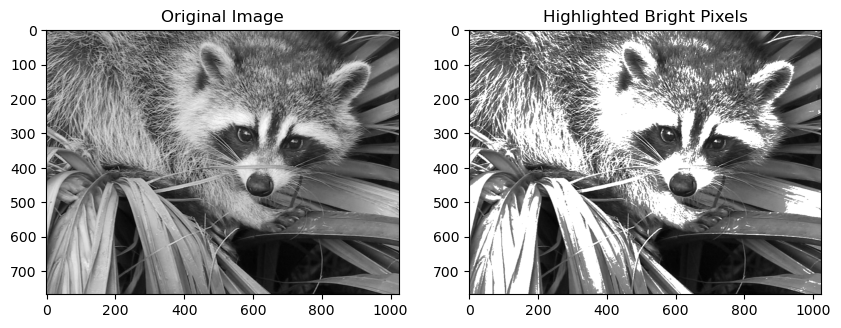

In [3]:
# Load a standard grayscale image of a raccoon's face
face = scipy.datasets.face(gray=True)

# Create a mask for all pixels with a brightness value above 150
bright_mask = face > 150

# Let's create a copy and set all these bright pixels to a very high value (255 = white)
highlighted_face = face.copy()
highlighted_face[bright_mask] = 255

# Display both images side-by-side
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(face, cmap=plt.cm.gray)
axs[0].set_title('Original Image')

axs[1].imshow(highlighted_face, cmap=plt.cm.gray)
axs[1].set_title('Highlighted Bright Pixels')
plt.show()

**Extra:** Be creative and modify the image in whatever way you wish :)

<span style="background-color: #f8bbd0; color: black; padding: 2px 5px; border-radius: 3px;">**Task B.2**</span> Using the raccoon face image, your task is to darken the lower half of the image.

1. Get the shape of the `face` array to find out its height.
2. Create a copy of the `face` array to work on.
3. Use array **slicing** to select the bottom half of the copied image.
4. Multiply this selection by `0.5` to reduce its brightness by 50%.
5. Display the new, modified image.

In [4]:
# Your solution here
face = scipy.misc.face(gray=True)

# 1. Get image height
height = face.shape[0]

# 2. Create a copy
darkened_face = face.copy()

# 3. & 4. Select the bottom half and darken it
darkened_face[height // 2:, :] = darkened_face[height // 2:, :] * 0.5

# 5. Display the result
plt.imshow(darkened_face, cmap=plt.cm.gray)
plt.title('Lower Half Darkened')
plt.show()

## Linear Algebra with `numpy.linalg`

Many problems in physics can be described as a system of linear equations. NumPy's linear algebra submodule, `numpy.linalg`, provides efficient tools to solve these systems.

A system of equations like:
$a_{11}x_1 + a_{12}x_2 = b_1$
$a_{21}x_1 + a_{22}x_2 = b_2$

can be written in matrix form as $A\vec{x} = \vec{b}$, where $A$ is the matrix of coefficients, $\vec{x}$ is the vector of unknowns, and $\vec{b}$ is the vector of constants. We can solve for $\vec{x}$ using `np.linalg.solve(A, b)`.

In [5]:
# Example: Solve the system 3x + 2y = 11 and x + 4y = 17

# 1. Define the coefficient matrix A and the constant vector b
A = np.array([[3, 2],
                [1, 4]])

b = np.array([11, 17])

# 2. Solve the system
solution = np.linalg.solve(A, b)

print(f"Solution (x, y): {solution}")

Solution (x, y): [1. 4.]

<span style="background-color: #f8bbd0; color: black; padding: 2px 5px; border-radius: 3px;">**Task B.3**</span> Solve the following system of linear equations for $x$, $y$, and $z$.

$2x + y - z = 8$

$-3x - y + 2z = -11$

$-2x + y + 2z = -3$

1. Set up the 3x3 coefficient matrix `A` and the 3-element constant vector `b`.
2. Use `np.linalg.solve()` to find the solution vector.
3. Print the results for $x$, $y$, and $z$.

In [4]:
# Your solution here

# 1. Define the coefficient matrix A and the constant vector b
A = np.array([[2, 1, -1],
                [-3, -1, 2],
                [-2, 1, 2]])

b = np.array([8, -11, -3])

# 2. Solve the system
solution = np.linalg.solve(A, b)

# 3. Print the results
print(f"The solution is (x, y, z): {solution}")
print(f"x = {solution[0]}, y = {solution[1]}, z = {solution[2]}")

The solution is (x, y, z): [ 2.  3. -1.]
x = 2.0000000000000004, y = 2.9999999999999996, z = -0.9999999999999991
